# Multi-Factor Exposure Analyser

**Asset-allocation track · Project 2 of 6.** The first question any allocator asks a manager who
claims alpha is whether it survives a factor regression. Most "alpha" is repackaged exposure to
size, value, momentum or quality that can be bought for a few basis points in an ETF.

This notebook regresses any stock, ETF, fund or portfolio on the Fama-French factor models and
answers:

| Question | Where |
|---|---|
| How much of the return is explained by known factors, and how much is left? | §5 model comparison |
| Which factors, how strongly, and are the loadings statistically meaningful? | §6 coefficient plot with Newey-West errors |
| Have the exposures been stable, or has the strategy drifted? | §7 rolling loadings and style map |
| Where did the return actually come from? | §8 attribution |
| Can the regression be trusted? | §9 residual diagnostics |
| Across a whole set of funds, who has alpha after correcting for multiple testing? | §10 cross-section |

**Data:** Kenneth French Data Library (US daily and monthly factors 1963→; Developed ex-US and
Emerging monthly factors), Yahoo Finance for asset prices. Standard errors are Newey-West HAC,
computed from first principles and verified against `statsmodels` in the test-suite.

## 1. Setup

In [1]:
import importlib, subprocess, sys
def ensure(pkg, mod):
    try: importlib.import_module(mod); return
    except ImportError: pass
    for extra in ([], ["--break-system-packages"]):
        if subprocess.call([sys.executable, "-m", "pip", "install", "-q", pkg] + extra) == 0: return
    print(f"WARNING: could not install {pkg}")
for pkg, mod in [("yfinance", "yfinance"), ("scipy", "scipy")]:
    ensure(pkg, mod)
print("dependencies ready")

dependencies ready


In [2]:
import os, sys, warnings, logging, time
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s")
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive"); os.chdir("/content/drive/MyDrive/factor-exposure-analyser")
for d in ["src/factorlens", "data/cache", "outputs/figures", "outputs/tables", "tests"]:
    os.makedirs(d, exist_ok=True)
if os.path.abspath("src") not in sys.path:
    sys.path.insert(0, os.path.abspath("src"))
print("working directory:", os.getcwd())

working directory: /tmp/nb2


## 2. Package source

```
factor-exposure-analyser/
├── notebooks/factor_exposure_analyser.ipynb
├── src/factorlens/
│   ├── config.py     assets, portfolio, French file registry, model definitions, settings
│   ├── data.py       shared loader (same as Project 1): Yahoo prices, calendar alignment, FX, bad-print repair
│   ├── french.py     Kenneth French library download, robust parsing, factor-set assembly
│   ├── factors.py    OLS + Newey-West, model comparison, rolling, attribution, diagnostics, cross-section
│   └── plots.py      figures
├── tests/test_factorlens.py   10 offline tests (incl. exact match to statsmodels HAC)
└── outputs/{figures,tables}
```

### `factorlens/__init__.py`

Package version.

In [3]:
%%writefile src/factorlens/__init__.py
"""factorlens - multi-factor exposure analyser (asset-allocation track, project 2)."""
__version__ = "1.0.0"

Writing src/factorlens/__init__.py


### `factorlens/config.py`

Assets chosen so each illustrates a factor (value, momentum, quality, size, min-vol, and two active names), the Project-1 portfolio for the blended case, the French library file registry, and the five model definitions (CAPM, FF3, Carhart 4, FF5, FF5+Mom).

In [4]:
%%writefile src/factorlens/config.py
"""
Configuration for the multi-factor exposure analyser.
"""
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

# --------------------------------------------------------------------------- #
# Assets to analyse. Chosen so each one tells a factor story.
# --------------------------------------------------------------------------- #
ASSETS: Dict[str, str] = {
    "BRK-B": "Berkshire Hathaway (is Buffett's alpha just quality + low beta?)",
    "ARKK": "ARK Innovation (growth, high beta, style drift)",
    "VTV": "Vanguard Value ETF (should load on HML)",
    "MTUM": "iShares Momentum ETF (should load on Mom)",
    "QUAL": "iShares Quality ETF (should load on RMW)",
    "IWM": "Russell 2000 ETF (should load on SMB)",
    "USMV": "iShares Min Vol ETF (beta well below 1)",
}

# A portfolio can be analysed as a single asset (monthly-rebalanced blend).
PORTFOLIO: Dict[str, float] = {"SPY": 0.30, "QQQ": 0.10, "EFA": 0.10, "EEM": 0.05, "IEF": 0.15,
                               "TLT": 0.10, "LQD": 0.05, "GLD": 0.10, "VNQ": 0.05}
PORTFOLIO_NAME = "Project-1 multi-asset portfolio"

# --------------------------------------------------------------------------- #
# Kenneth French library files. Each entry: (file stem, frequency, columns)
# --------------------------------------------------------------------------- #
FRENCH_BASE = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{stem}_CSV.zip"

FACTOR_FILES: Dict[str, Dict[str, str]] = {
    # US
    "us_3_monthly": dict(stem="F-F_Research_Data_Factors", freq="M"),
    "us_3_daily": dict(stem="F-F_Research_Data_Factors_daily", freq="D"),
    "us_5_monthly": dict(stem="F-F_Research_Data_5_Factors_2x3", freq="M"),
    "us_5_daily": dict(stem="F-F_Research_Data_5_Factors_2x3_daily", freq="D"),
    "us_mom_monthly": dict(stem="F-F_Momentum_Factor", freq="M"),
    "us_mom_daily": dict(stem="F-F_Momentum_Factor_daily", freq="D"),
    # International (monthly only)
    "dev_ex_us_5_monthly": dict(stem="Developed_ex_US_5_Factors", freq="M"),
    "dev_ex_us_mom_monthly": dict(stem="Developed_ex_US_Mom_Factor", freq="M"),
    "emerging_5_monthly": dict(stem="Emerging_5_Factors", freq="M"),
    "emerging_mom_monthly": dict(stem="Emerging_MOM_Factor", freq="M"),
}

# Model definitions: name -> factor columns (excess market return is 'Mkt-RF').
MODELS: Dict[str, List[str]] = {
    "CAPM": ["Mkt-RF"],
    "FF3": ["Mkt-RF", "SMB", "HML"],
    "Carhart4": ["Mkt-RF", "SMB", "HML", "Mom"],
    "FF5": ["Mkt-RF", "SMB", "HML", "RMW", "CMA"],
    "FF5+Mom": ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"],
}


@dataclass
class DataConfig:
    start: str = "2005-01-01"
    end: Optional[str] = None
    cache_dir: str = "data/cache"
    fred_series: str = "DGS3MO"          # unused for regressions (French supplies RF) but kept for the shared loader
    base_currency: str = "USD"
    trading_days: int = 252
    min_history_fraction: float = 0.0    # assets with short history are allowed; regressions use available overlap


@dataclass
class AnalysisConfig:
    frequency: str = "M"                 # "M" monthly (standard) or "D" daily
    region: str = "us"                   # us | dev_ex_us | emerging
    rolling_window: int = 36             # periods (36 months, or ~252 days if daily)
    min_obs: int = 24                    # minimum observations for any regression
    hac_lags: Optional[int] = None       # None -> Newey-West automatic rule 4(T/100)^(2/9)
    confidence: float = 0.95


DATA = DataConfig()
ANALYSIS = AnalysisConfig()

Writing src/factorlens/config.py


### `factorlens/data.py`

The shared data layer from Project 1 with one change: assets keep their own history instead of being truncated to a common start, because a factor regression should use every observation the asset has.

In [5]:
%%writefile src/factorlens/data.py
"""
Data acquisition layer (shared across the asset-allocation track; identical to Project 1).

Responsibilities
----------------
* Download adjusted prices from Yahoo Finance with local caching.
* Download the risk-free rate from FRED (no API key required).
* Build a point-in-time market-cap proxy (current shares outstanding x
  historical price) for Black-Litterman equilibrium weights.
* Run data-quality checks and fail loudly on problems that would corrupt
  downstream estimates.
* Provide a synthetic fallback so the pipeline can be unit-tested offline.

Every public function returns pandas objects indexed by a tz-naive
DatetimeIndex and aligned to the trading calendar of the price data.
"""
from __future__ import annotations

import io
import logging
import os
import time
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests

from .config import DATA, DataConfig

logger = logging.getLogger(__name__)

FRED_CSV_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def _cache_path(cfg: DataConfig, name: str) -> str:
    os.makedirs(cfg.cache_dir, exist_ok=True)
    return os.path.join(cfg.cache_dir, name)


def _retry(fn, attempts: int = 3, wait: float = 2.0, label: str = "call"):
    """Retry a callable with linear back-off. Re-raises the last exception."""
    last_exc: Optional[Exception] = None
    for i in range(1, attempts + 1):
        try:
            return fn()
        except Exception as exc:  # noqa: BLE001 - we want to retry on anything
            last_exc = exc
            logger.warning("%s failed (attempt %d/%d): %s", label, i, attempts, exc)
            time.sleep(wait * i)
    assert last_exc is not None
    raise last_exc


# --------------------------------------------------------------------------- #
# Prices
# --------------------------------------------------------------------------- #
def load_prices(tickers: Iterable[str],
                cfg: DataConfig = DATA,
                force_refresh: bool = False) -> pd.DataFrame:
    """
    Adjusted close prices, one column per ticker.

    Prices are cached to CSV keyed on the ticker set and date range.
    Adjusted closes (auto_adjust=True) already incorporate splits and
    dividends, so simple returns on them are total returns.
    """
    tickers = sorted(set(tickers))
    end = cfg.end or pd.Timestamp.today().strftime("%Y-%m-%d")
    cache = _cache_path(cfg, f"prices_{cfg.start}_{end}_{len(tickers)}.csv")

    if os.path.exists(cache) and not force_refresh:
        prices = pd.read_csv(cache, index_col=0, parse_dates=True)
        if set(prices.columns) == set(tickers):
            logger.info("Loaded %d tickers from cache %s", len(tickers), cache)
            return prices[tickers]

    import yfinance as yf  # imported lazily so tests can run without it

    def _download() -> pd.DataFrame:
        raw = yf.download(tickers, start=cfg.start, end=end,
                          auto_adjust=True, progress=False, threads=True)
        if raw.empty:
            raise RuntimeError("Yahoo Finance returned an empty frame")
        close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
        if isinstance(close, pd.Series):
            close = close.to_frame(tickers[0])
        return close

    prices = _retry(_download, label="yfinance download")
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index()
    prices.columns = [str(c) for c in prices.columns]
    prices = prices.reindex(columns=tickers)

    try:
        prices.to_csv(cache)
    except Exception as exc:  # read-only filesystem etc. - caching is best-effort
        logger.warning("Could not write price cache: %s", exc)
    return prices


def repair_bad_prints(prices: pd.DataFrame, threshold: float = 0.5,
                      lookahead: int = 5, tol: float = 0.2) -> Tuple[pd.DataFrame, Dict[str, int]]:
    """
    Blank out price spikes that reverse within `lookahead` days.

    A genuine crash does not un-crash in a week; an unadjusted split does not
    reverse at all. Only the self-reversing pattern is treated as an error.
    Returns the repaired frame and a per-ticker count of repaired prints.
    """
    px = prices.copy()
    fixed: Dict[str, int] = {}
    for t in px.columns:
        s = px[t]
        r = s.pct_change()
        bad = r.index[r.abs() > threshold]
        for d in bad:
            i = s.index.get_loc(d)
            base = s.iloc[i - 1]
            if not np.isfinite(base) or base <= 0:
                continue
            window = s.iloc[i: i + lookahead + 1]
            back = (window / base - 1).abs()
            hits = np.where(back.values[1:] < tol)[0]
            if len(hits):
                j = i + 1 + hits[0]                      # first index back near the base
                px.loc[s.index[i]: s.index[j - 1], t] = np.nan
                fixed[t] = fixed.get(t, 0) + (j - i)
    return px, fixed


def clean_prices(prices: pd.DataFrame,
                 cfg: DataConfig = DATA) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """
    Data-quality gate.

    * Drops tickers with insufficient history.
    * Forward-fills isolated gaps (max 5 days) and reports them.
    * Drops any leading rows where not every ticker has a price.
    * Raises on non-positive prices or on duplicated dates.

    Returns the cleaned frame and a dict of issues found, for the report.
    """
    issues: Dict[str, str] = {}
    px = prices.copy()

    if px.index.duplicated().any():
        raise ValueError("Duplicated dates in price index")

    # 1. Cross-exchange calendars: drop days on which most of the universe was
    #    closed (e.g. an Indian holiday in a mixed India/US list). Dropping a
    #    row is safe for returns because pct_change compounds across the gap;
    #    forward-filling instead would create artificial zero-return days.
    row_cov = px.notna().mean(axis=1)
    dropped_days = int((row_cov < 0.5).sum())
    if dropped_days:
        issues["_calendar"] = f"dropped {dropped_days} days when <50% of tickers traded"
    px = px[row_cov >= 0.5]

    # 2. Repair self-reversing bad prints: a move beyond +/-50% that is undone
    #    within 5 days (cumulative move back within 20% of the start) is a data
    #    error, not a market event. Blank the bad prices so step 3 fills them.
    px, glitches = repair_bad_prints(px)
    for t, n in glitches.items():
        issues[t] = issues.get(t, "") + f"repaired {n} bad print(s); "

    # 3. Fill the remaining isolated gaps (single-exchange holidays, bad ticks).
    #    Leading NaNs (asset not yet listed) are deliberately left alone.
    was_na = px.isna()
    px = px.ffill(limit=5)
    gap_counts = (was_na & px.notna()).sum()
    for t in px.columns:
        first = px[t].first_valid_index()
        if first is not None and first > px.index[0]:
            issues[t] = issues.get(t, "") + f"history starts {first.date()}; "

    # 4. Tickers with insufficient history (listed after `start`, delisted, etc).
    coverage = px.notna().mean()
    thin = coverage[coverage < cfg.min_history_fraction]
    for t, c in thin.items():
        first = px[t].first_valid_index()
        issues[t] = (f"dropped: only {c:.1%} of dates have a price"
                     + (f" (first price {first.date()}; move DataConfig.start later to keep it)" if first is not None else ""))
    px = px.drop(columns=thin.index)
    for t, n in gap_counts.reindex(px.columns).items():
        if n > 0:
            issues[t] = issues.get(t, "") + f"filled {int(n)} missing price(s)"

    # Keep each asset's own history: rows are dropped only when *every* asset is
    # missing. Downstream code (alignment, regressions) drops NaNs per asset.
    px = px.dropna(how="all")

    if (px <= 0).any().any():
        bad = px.columns[(px <= 0).any()].tolist()
        raise ValueError(f"Non-positive prices found for {bad}")

    return px, issues


def compute_returns(prices: pd.DataFrame) -> pd.DataFrame:
    """Simple daily returns. Simple (not log) because portfolio returns aggregate linearly."""
    rets = prices.pct_change(fill_method=None).iloc[1:]
    # Guard against corporate-action glitches that produce absurd single-day moves.
    extreme = (rets.abs() > 0.5)
    if extreme.any().any():
        n = int(extreme.sum().sum())
        logger.warning("%d daily returns exceed +/-50%%; inspect before trusting results", n)
    return rets


# --------------------------------------------------------------------------- #
# Currency conversion
# --------------------------------------------------------------------------- #
def fetch_currencies(tickers: Iterable[str]) -> pd.Series:
    """Quote currency per ticker from yfinance (e.g. USD, INR, JPY, GBp)."""
    out: Dict[str, str] = {}
    try:
        import yfinance as yf
        for t in tickers:
            try:
                out[t] = str(yf.Ticker(t).fast_info.get("currency") or "USD")
            except Exception as exc:  # noqa: BLE001
                logger.warning("currency lookup failed for %s; assuming USD: %s", t, exc)
                out[t] = "USD"
    except ImportError:
        out = {t: "USD" for t in tickers}
    return pd.Series(out, name="currency")


def convert_to_base_currency(prices: pd.DataFrame, base: str = "USD",
                             currencies: Optional[pd.Series] = None,
                             cfg: DataConfig = DATA) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """
    Convert every column to `base` using Yahoo FX crosses (e.g. INRUSD=X).

    GBp (pence) and ZAc (cents) are scaled to their major unit first. FX
    series are forward-filled onto the price calendar. Returns the converted
    frame and a log of what was converted. No-op for single-currency
    universes already quoted in `base`.
    """
    log: Dict[str, str] = {}
    cur = currencies if currencies is not None else fetch_currencies(prices.columns)
    cur = cur.reindex(prices.columns).fillna(base)
    px = prices.copy()

    minor = {"GBp": ("GBP", 100.0), "ZAc": ("ZAR", 100.0), "ILA": ("ILS", 100.0)}
    for t, c in cur.items():
        if c in minor:
            major, div = minor[c]
            px[t] = px[t] / div
            cur[t] = major

    needed = sorted(set(cur) - {base})
    if not needed:
        return px, log

    import yfinance as yf
    end = cfg.end or pd.Timestamp.today().strftime("%Y-%m-%d")
    for c in needed:
        pair = f"{c}{base}=X"
        def _dl(pair=pair):
            fx = yf.download(pair, start=cfg.start, end=end, auto_adjust=True, progress=False)
            if fx.empty:
                raise RuntimeError(f"no FX data for {pair}")
            fx = fx["Close"]
            return fx.iloc[:, 0] if isinstance(fx, pd.DataFrame) else fx
        try:
            fx = _retry(_dl, label=f"FX {pair}")
        except Exception as exc:  # noqa: BLE001
            raise RuntimeError(f"Could not download {pair}; cannot express {c} assets in {base}") from exc
        fx.index = pd.to_datetime(fx.index).tz_localize(None)
        fx = fx.reindex(px.index.union(fx.index)).ffill().reindex(px.index)
        cols = [t for t, cc in cur.items() if cc == c]
        px[cols] = px[cols].mul(fx, axis=0)
        log[c] = f"{len(cols)} ticker(s) converted via {pair}"
    return px, log


# --------------------------------------------------------------------------- #
# Risk-free rate
# --------------------------------------------------------------------------- #
def load_risk_free(index: pd.DatetimeIndex,
                   cfg: DataConfig = DATA,
                   force_refresh: bool = False) -> pd.Series:
    """
    Daily risk-free rate aligned to `index`, derived from a FRED yield series
    quoted in percent (annualised, bond-equivalent). Falls back to zero with a
    loud warning if FRED is unreachable, so the pipeline never silently uses a
    stale number.
    """
    cache = _cache_path(cfg, f"fred_{cfg.fred_series}.csv")
    try:
        if os.path.exists(cache) and not force_refresh:
            raw = pd.read_csv(cache, index_col=0, parse_dates=True)
        else:
            resp = _retry(lambda: requests.get(FRED_CSV_URL.format(series=cfg.fred_series), timeout=30),
                          label="FRED download")
            resp.raise_for_status()
            raw = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
            raw.to_csv(cache)
        yld = pd.to_numeric(raw.iloc[:, 0], errors="coerce")
    except Exception as exc:  # noqa: BLE001
        logger.error("Risk-free download failed (%s). Using 0%% - Sharpe ratios will be overstated.", exc)
        return pd.Series(0.0, index=index, name="rf_daily")

    yld = yld.reindex(index.union(yld.index)).ffill().reindex(index)
    yld = yld.fillna(0.0)
    daily = (1.0 + yld / 100.0) ** (1.0 / cfg.trading_days) - 1.0
    daily.name = "rf_daily"
    return daily


# --------------------------------------------------------------------------- #
# Synthetic fallback (offline tests / demos)
# --------------------------------------------------------------------------- #
def synthetic_prices(tickers: List[str],
                     n_days: int = 2520,
                     seed: int = 7,
                     start: str = "2015-01-01") -> pd.DataFrame:
    """
    Geometric Brownian motion with a one-factor correlation structure.
    Deterministic given `seed`. Used only when live data is unavailable.
    """
    rng = np.random.default_rng(seed)
    n = len(tickers)
    beta = rng.uniform(0.6, 1.4, n)
    idio = rng.uniform(0.15, 0.35, n) / np.sqrt(252)
    mkt = rng.normal(0.0004, 0.011, n_days)
    eps = rng.normal(0, 1, (n_days, n)) * idio
    rets = np.outer(mkt, beta) + eps + rng.uniform(0.0, 0.0003, n)
    idx = pd.bdate_range(start, periods=n_days)
    return pd.DataFrame(100 * np.cumprod(1 + rets, axis=0), index=idx, columns=tickers)


def load_all(tickers: Iterable[str], cfg: DataConfig = DATA,
             use_synthetic: bool = False) -> Dict[str, object]:
    """
    One-call loader: prices (base currency), daily returns, daily risk-free,
    and an issues log. `tickers` should include the benchmark constituents.
    """
    tickers = list(dict.fromkeys(tickers))          # de-duplicate, keep order
    if use_synthetic:
        logger.warning("Using SYNTHETIC prices - results are illustrative only")
        prices = synthetic_prices(tickers)
        issues: Dict[str, str] = {"_mode": "synthetic"}
        returns = compute_returns(prices)
        rf = pd.Series(0.02 / cfg.trading_days, index=returns.index, name="rf_daily")
    else:
        prices = load_prices(tickers, cfg)
        prices, issues = clean_prices(prices, cfg)
        prices, fx_log = convert_to_base_currency(prices, cfg.base_currency, cfg=cfg)
        prices = prices.dropna(how="all")
        issues.update({f"_fx_{k}": v for k, v in fx_log.items()})
        returns = compute_returns(prices)
        rf = load_risk_free(returns.index, cfg)
    return dict(prices=prices, returns=returns, rf=rf, issues=issues)

Writing src/factorlens/data.py


### `factorlens/french.py`

Downloads the zipped CSVs, parses the first data block by scanning for date rows (the files have free-text headers, an annual block and a copyright footer), converts percent to decimal, treats −99.99 as missing, caches, and assembles Mkt-RF/SMB/HML/RMW/CMA/Mom/RF for US (daily or monthly), Developed ex-US and Emerging (monthly).

In [6]:
%%writefile src/factorlens/french.py
"""
Kenneth French Data Library loader.

The library publishes zipped CSVs with a free-text header, one or more data
blocks (monthly then annual, or a single daily block) and a copyright footer.
Dates are YYYYMM (monthly) or YYYYMMDD (daily). Values are in percent.

This module downloads (with caching), parses the *first* data block robustly
by scanning for date-like rows, converts to decimal returns and returns a
DataFrame indexed by period end. It also assembles the factor sets used by
the models (3, 5, 5+Mom) for a region and frequency.
"""
from __future__ import annotations

import io
import logging
import os
import re
import time
import zipfile
from typing import Dict, List, Optional

import pandas as pd
import requests

from .config import DATA, FACTOR_FILES, FRENCH_BASE, DataConfig

logger = logging.getLogger(__name__)

_DATE_ROW = re.compile(r"^\s*(\d{6}|\d{8})\s*,")


def parse_french_csv(text: str) -> pd.DataFrame:
    """
    Parse the first data block of a French CSV. Returns decimal returns with a
    DatetimeIndex at period end (month end for YYYYMM, the day for YYYYMMDD).
    """
    lines = text.splitlines()
    header_idx = None
    rows: List[str] = []
    for i, line in enumerate(lines):
        if _DATE_ROW.match(line):
            if header_idx is None:
                # the column header is the nearest previous non-empty line
                j = i - 1
                while j >= 0 and not lines[j].strip():
                    j -= 1
                header_idx = j
            rows.append(line)
        elif rows:
            break                        # first blank / non-date line after the block ends it
    if not rows or header_idx is None:
        raise ValueError("No data block found in French CSV")

    header = [h.strip() for h in lines[header_idx].split(",")]
    header[0] = "date"
    df = pd.read_csv(io.StringIO("\n".join(rows)), header=None, names=header, skipinitialspace=True)
    key = df["date"].astype(str).str.strip()
    if key.str.len().iloc[0] == 6:
        df.index = pd.to_datetime(key, format="%Y%m") + pd.offsets.MonthEnd(0)
    else:
        df.index = pd.to_datetime(key, format="%Y%m%d")
    df = df.drop(columns="date").astype(float) / 100.0
    df.index.name = "date"
    # French uses -99.99 / -999 as missing markers
    df = df.mask(df <= -0.99)
    return df


def _retry(fn, attempts=3, wait=2.0, label="download"):
    last = None
    for i in range(1, attempts + 1):
        try:
            return fn()
        except Exception as exc:  # noqa: BLE001
            last = exc
            logger.warning("%s failed (attempt %d/%d): %s", label, i, attempts, exc)
            time.sleep(wait * i)
    raise last  # type: ignore[misc]


def load_french_file(key: str, cfg: DataConfig = DATA, force_refresh: bool = False) -> pd.DataFrame:
    """Download (or read from cache) one library file by its FACTOR_FILES key."""
    meta = FACTOR_FILES[key]
    os.makedirs(cfg.cache_dir, exist_ok=True)
    cache = os.path.join(cfg.cache_dir, f"french_{key}.csv")
    if os.path.exists(cache) and not force_refresh:
        return pd.read_csv(cache, index_col=0, parse_dates=True)

    url = FRENCH_BASE.format(stem=meta["stem"])
    def _dl():
        r = requests.get(url, timeout=60, headers={"User-Agent": "factor-exposure-analyser/1.0"})
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
        return z.read(name).decode("latin1")
    text = _retry(_dl, label=f"French {key}")
    df = parse_french_csv(text)
    df.to_csv(cache)
    logger.info("French %s: %d rows %s -> %s", key, len(df), df.index[0].date(), df.index[-1].date())
    return df


def load_factors(region: str = "us", frequency: str = "M", cfg: DataConfig = DATA,
                 include_momentum: bool = True) -> pd.DataFrame:
    """
    Assemble Mkt-RF, SMB, HML, RMW, CMA, (Mom), RF for a region and frequency.

    US: daily or monthly. International regions: monthly only (French does not
    publish daily international factors). Momentum is merged from its own file.
    """
    freq = frequency.upper()
    if region == "us":
        five = load_french_file("us_5_monthly" if freq == "M" else "us_5_daily", cfg)
        mom = load_french_file("us_mom_monthly" if freq == "M" else "us_mom_daily", cfg) if include_momentum else None
    elif region in ("dev_ex_us", "emerging"):
        if freq != "M":
            raise ValueError("International factors are monthly only")
        five = load_french_file(f"{region}_5_monthly", cfg)
        mom = load_french_file(f"{region}_mom_monthly", cfg) if include_momentum else None
    else:
        raise ValueError(f"Unknown region {region}; use us | dev_ex_us | emerging")

    df = five.copy()
    if mom is not None:
        mom_col = [c for c in mom.columns if c.lower().startswith("mom") or c.upper() == "WML"][0]
        df = df.join(mom[[mom_col]].rename(columns={mom_col: "Mom"}), how="left")
    # Standardise column names across files (international files use 'Mkt-RF' too, but be safe)
    df.columns = [c.replace(" ", "") for c in df.columns]
    if "WML" in df.columns:
        df = df.rename(columns={"WML": "Mom"})
    wanted = [c for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom", "RF"] if c in df.columns]
    df = df[wanted].dropna(subset=["Mkt-RF"])
    df.attrs["region"] = region
    df.attrs["frequency"] = freq
    return df


def factor_descriptions() -> Dict[str, str]:
    return {
        "Mkt-RF": "Market excess return (value-weighted market minus 1-month T-bill)",
        "SMB": "Small minus big: size premium",
        "HML": "High minus low book-to-market: value premium",
        "RMW": "Robust minus weak operating profitability: quality/profitability premium",
        "CMA": "Conservative minus aggressive investment: investment premium",
        "Mom": "Winners minus losers over months t-12 to t-2: momentum premium",
        "RF": "One-month Treasury bill rate",
    }

Writing src/factorlens/french.py


### `factorlens/factors.py`

OLS by least squares; Newey-West HAC covariance with the Bartlett kernel and the 4(T/100)^(2/9) lag rule; model comparison table (alpha, OLS and HAC t-stats, R², information ratio, AIC/BIC); rolling regressions with HAC t-stats; style-drift statistics; return attribution (alpha + Σ β·E[f]) with cumulative paths; Jarque-Bera, Ljung-Box, Durbin-Watson and ARCH-LM diagnostics; cross-sectional table with Benjamini-Hochberg adjusted p-values.

In [7]:
%%writefile src/factorlens/factors.py
"""
Factor regressions.

    r_it - rf_t = alpha_i + sum_k beta_ik f_kt + e_it

Implemented from first principles with numpy so the arithmetic is visible and
testable: OLS point estimates, Newey-West (1987) HAC standard errors with the
Bartlett kernel, model comparison, rolling regressions, return attribution
and residual diagnostics.

Why HAC errors
--------------
Monthly fund returns are mildly autocorrelated and strongly heteroskedastic
(volatility clusters). Plain OLS standard errors understate the uncertainty
of alpha, sometimes by a lot. Newey-West corrects both problems and is the
standard in the empirical asset-pricing literature.
"""
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from scipy import stats

from .config import ANALYSIS, MODELS, AnalysisConfig

PERIODS = {"M": 12, "D": 252, "W": 52}


# --------------------------------------------------------------------------- #
# Alignment
# --------------------------------------------------------------------------- #
def to_monthly(daily_returns: pd.DataFrame | pd.Series) -> pd.DataFrame | pd.Series:
    """
    Compound daily simple returns to calendar-month returns (month-end index).
    Months with no observations stay NaN (min_count=1), otherwise pandas would
    report an empty product as a 0% return for assets not yet listed.
    """
    return (1 + daily_returns).resample("ME").prod(min_count=1) - 1


def align(asset_returns: pd.DataFrame, factors: pd.DataFrame, frequency: str = "M") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Put asset and factor returns on the same calendar. Daily asset returns are
    compounded to monthly when frequency == "M". Returns (excess_asset_returns, factors).
    """
    r = to_monthly(asset_returns) if frequency.upper() == "M" else asset_returns.copy()
    if frequency.upper() == "M":
        r.index = r.index + pd.offsets.MonthEnd(0)
    idx = r.index.intersection(factors.index)
    r, f = r.loc[idx], factors.loc[idx]
    excess = r.sub(f["RF"], axis=0)
    return excess, f


# --------------------------------------------------------------------------- #
# OLS + Newey-West
# --------------------------------------------------------------------------- #
@dataclass
class RegressionResult:
    asset: str
    model: str
    factors: List[str]
    n_obs: int
    frequency: str
    alpha: float                      # per period
    betas: pd.Series
    se_ols: pd.Series                 # incl. 'alpha'
    se_hac: pd.Series                 # incl. 'alpha'
    hac_lags: int
    r2: float
    adj_r2: float
    resid: pd.Series
    fitted: pd.Series
    X: pd.DataFrame
    y: pd.Series

    @property
    def periods(self) -> int:
        return PERIODS[self.frequency]

    @property
    def alpha_ann(self) -> float:
        return self.alpha * self.periods

    @property
    def t_alpha_hac(self) -> float:
        return self.alpha / self.se_hac["alpha"]

    @property
    def t_alpha_ols(self) -> float:
        return self.alpha / self.se_ols["alpha"]

    @property
    def p_alpha_hac(self) -> float:
        return 2 * (1 - stats.t.cdf(abs(self.t_alpha_hac), df=self.n_obs - len(self.factors) - 1))

    @property
    def t_betas_hac(self) -> pd.Series:
        return self.betas / self.se_hac[self.factors]

    @property
    def resid_vol_ann(self) -> float:
        return float(self.resid.std(ddof=len(self.factors) + 1) * np.sqrt(self.periods))

    @property
    def information_ratio(self) -> float:
        """Alpha per unit of idiosyncratic risk (appraisal ratio)."""
        return self.alpha_ann / self.resid_vol_ann if self.resid_vol_ann > 0 else np.nan

    @property
    def aic(self) -> float:
        k = len(self.factors) + 1
        rss = float((self.resid ** 2).sum())
        return self.n_obs * np.log(rss / self.n_obs) + 2 * k

    @property
    def bic(self) -> float:
        k = len(self.factors) + 1
        rss = float((self.resid ** 2).sum())
        return self.n_obs * np.log(rss / self.n_obs) + k * np.log(self.n_obs)

    def summary_row(self) -> Dict[str, float]:
        row = {"n_obs": self.n_obs, "alpha_ann": self.alpha_ann, "t_alpha_ols": self.t_alpha_ols,
               "t_alpha_hac": self.t_alpha_hac, "p_alpha_hac": self.p_alpha_hac,
               "r2": self.r2, "adj_r2": self.adj_r2, "resid_vol_ann": self.resid_vol_ann,
               "info_ratio": self.information_ratio, "aic": self.aic, "bic": self.bic}
        for f in self.factors:
            row[f"beta_{f}"] = self.betas[f]
            row[f"t_{f}"] = self.t_betas_hac[f]
        return row


def newey_west_lags(n: int) -> int:
    """Newey-West (1994) rule of thumb: floor(4 (T/100)^(2/9))."""
    return int(np.floor(4 * (n / 100.0) ** (2.0 / 9.0)))


def _hac_cov(X: np.ndarray, e: np.ndarray, lags: int) -> np.ndarray:
    """Newey-West covariance of the OLS coefficients with a Bartlett kernel."""
    n, k = X.shape
    xe = X * e[:, None]
    S = xe.T @ xe
    for l in range(1, lags + 1):
        w = 1.0 - l / (lags + 1.0)
        G = xe[l:].T @ xe[:-l]
        S += w * (G + G.T)
    XtX_inv = np.linalg.inv(X.T @ X)
    return XtX_inv @ S @ XtX_inv


def regress(y: pd.Series, X: pd.DataFrame, asset: str = "", model: str = "",
            frequency: str = "M", hac_lags: Optional[int] = None,
            min_obs: int = ANALYSIS.min_obs) -> RegressionResult:
    """OLS of excess returns on factors with an intercept; OLS and HAC standard errors."""
    df = pd.concat([y.rename("y"), X], axis=1).dropna()
    if len(df) < min_obs:
        raise ValueError(f"{asset}/{model}: only {len(df)} observations (< {min_obs})")
    yv = df["y"].values.astype(float)
    Xm = np.column_stack([np.ones(len(df)), df[X.columns].values.astype(float)])
    n, k = Xm.shape
    beta, *_ = np.linalg.lstsq(Xm, yv, rcond=None)
    fitted = Xm @ beta
    e = yv - fitted
    rss = float(e @ e)
    tss = float(((yv - yv.mean()) ** 2).sum())
    r2 = 1 - rss / tss if tss > 0 else np.nan
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k)
    sigma2 = rss / (n - k)
    cov_ols = sigma2 * np.linalg.inv(Xm.T @ Xm)
    lags = newey_west_lags(n) if hac_lags is None else int(hac_lags)
    cov_hac = _hac_cov(Xm, e, lags)
    names = ["alpha"] + list(X.columns)
    return RegressionResult(
        asset=asset, model=model, factors=list(X.columns), n_obs=n, frequency=frequency,
        alpha=float(beta[0]), betas=pd.Series(beta[1:], index=list(X.columns)),
        se_ols=pd.Series(np.sqrt(np.diag(cov_ols)), index=names),
        se_hac=pd.Series(np.sqrt(np.diag(cov_hac)), index=names), hac_lags=lags,
        r2=float(r2), adj_r2=float(adj_r2),
        resid=pd.Series(e, index=df.index), fitted=pd.Series(fitted, index=df.index),
        X=df[X.columns], y=df["y"])


# --------------------------------------------------------------------------- #
# Model comparison for one asset
# --------------------------------------------------------------------------- #
def fit_models(excess: pd.Series, factors: pd.DataFrame, asset: str,
               models: Dict[str, List[str]] = MODELS, cfg: AnalysisConfig = ANALYSIS
               ) -> Dict[str, RegressionResult]:
    out = {}
    for name, cols in models.items():
        missing = [c for c in cols if c not in factors.columns]
        if missing:
            continue
        out[name] = regress(excess, factors[cols], asset, name, cfg.frequency, cfg.hac_lags, cfg.min_obs)
    return out


def comparison_table(results: Dict[str, RegressionResult]) -> pd.DataFrame:
    return pd.DataFrame({m: r.summary_row() for m, r in results.items()}).T


def coefficient_table(res: RegressionResult, confidence: float = 0.95) -> pd.DataFrame:
    """Point estimates with OLS and HAC standard errors, t-stats and HAC confidence bands."""
    z = stats.t.ppf(0.5 + confidence / 2, df=res.n_obs - len(res.factors) - 1)
    est = pd.concat([pd.Series({"alpha": res.alpha}), res.betas])
    tbl = pd.DataFrame({"estimate": est, "se_ols": res.se_ols, "se_hac": res.se_hac})
    tbl["t_hac"] = tbl["estimate"] / tbl["se_hac"]
    tbl["ci_low"] = tbl["estimate"] - z * tbl["se_hac"]
    tbl["ci_high"] = tbl["estimate"] + z * tbl["se_hac"]
    tbl["hac_vs_ols"] = tbl["se_hac"] / tbl["se_ols"]
    return tbl


# --------------------------------------------------------------------------- #
# Rolling regressions and style drift
# --------------------------------------------------------------------------- #
def rolling_regression(excess: pd.Series, factors: pd.DataFrame, window: int,
                       frequency: str = "M", min_obs: Optional[int] = None) -> Dict[str, pd.DataFrame]:
    """
    Rolling OLS with HAC t-stats. Returns dict of DataFrames: 'coef', 'tstat',
    'r2' (Series). Alpha is per period in 'coef' and annualised in 'alpha_ann'.
    """
    df = pd.concat([excess.rename("y"), factors], axis=1).dropna()
    min_obs = min_obs or window
    coefs, tstats, r2s, idx = [], [], [], []
    for end in range(window, len(df) + 1):
        seg = df.iloc[end - window: end]
        try:
            r = regress(seg["y"], seg[factors.columns], frequency=frequency, min_obs=min_obs)
        except (ValueError, np.linalg.LinAlgError):
            continue
        coefs.append(pd.concat([pd.Series({"alpha": r.alpha}), r.betas]))
        tstats.append(pd.concat([pd.Series({"alpha": r.t_alpha_hac}), r.t_betas_hac]))
        r2s.append(r.r2); idx.append(seg.index[-1])
    coef = pd.DataFrame(coefs, index=idx); coef["alpha_ann"] = coef["alpha"] * PERIODS[frequency]
    return dict(coef=coef, tstat=pd.DataFrame(tstats, index=idx), r2=pd.Series(r2s, index=idx, name="r2"))


def style_drift(rolling_coef: pd.DataFrame, factors: List[str]) -> pd.DataFrame:
    """Dispersion and range of rolling betas; sign flips flag genuine drift."""
    rows = {}
    for f in factors:
        s = rolling_coef[f].dropna()
        rows[f] = dict(mean=s.mean(), std=s.std(), min=s.min(), max=s.max(),
                       range=s.max() - s.min(),
                       sign_flips=int((np.sign(s).diff().abs() > 0).sum()),
                       latest=s.iloc[-1])
    return pd.DataFrame(rows).T


# --------------------------------------------------------------------------- #
# Attribution
# --------------------------------------------------------------------------- #
def attribution(res: RegressionResult) -> Dict[str, object]:
    """
    Decompose average annualised excess return into alpha + beta_k * E[f_k] +
    residual (zero by construction in-sample), and build the cumulative
    contribution paths using additive period returns.
    """
    periods = res.periods
    fmeans = res.X.mean()
    contrib = (res.betas * fmeans) * periods
    total = float(res.y.mean() * periods)
    table = pd.concat([pd.Series({"alpha": res.alpha_ann}), contrib]).to_frame("ann_contribution")
    table["share_of_total"] = table["ann_contribution"] / total if total != 0 else np.nan
    table.loc["total_excess_return"] = [total, 1.0]
    cum = pd.DataFrame({f: (res.betas[f] * res.X[f]).cumsum() for f in res.factors})
    cum["alpha"] = res.alpha * np.arange(1, len(res.y) + 1)
    cum["residual"] = res.resid.cumsum()
    cum["actual"] = res.y.cumsum()
    return dict(table=table, cumulative=cum)


# --------------------------------------------------------------------------- #
# Residual diagnostics
# --------------------------------------------------------------------------- #
def ljung_box(x: np.ndarray, lags: int = 12) -> Tuple[float, float]:
    x = np.asarray(x) - np.mean(x)
    n = len(x)
    acf = np.array([np.sum(x[l:] * x[:-l]) / np.sum(x * x) for l in range(1, lags + 1)])
    q = n * (n + 2) * np.sum(acf ** 2 / (n - np.arange(1, lags + 1)))
    return float(q), float(1 - stats.chi2.cdf(q, lags))


def durbin_watson(e: np.ndarray) -> float:
    e = np.asarray(e)
    return float(np.sum(np.diff(e) ** 2) / np.sum(e ** 2))


def arch_lm(e: np.ndarray, lags: int = 4) -> Tuple[float, float]:
    """Engle's ARCH LM test on squared residuals (n R^2 ~ chi2(lags))."""
    e2 = np.asarray(e) ** 2
    y = e2[lags:]
    X = np.column_stack([np.ones(len(y))] + [e2[lags - l: -l] for l in range(1, lags + 1)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    r2 = 1 - np.sum((y - X @ b) ** 2) / np.sum((y - y.mean()) ** 2)
    lm = len(y) * r2
    return float(lm), float(1 - stats.chi2.cdf(lm, lags))


def residual_diagnostics(res: RegressionResult) -> pd.DataFrame:
    e = res.resid.values
    jb, jb_p = stats.jarque_bera(e)
    lb, lb_p = ljung_box(e, 12 if res.frequency == "M" else 20)
    arch, arch_p = arch_lm(e)
    rows = [
        ("Jarque-Bera (normality)", jb, jb_p, "residuals are normal"),
        ("Ljung-Box Q (autocorrelation)", lb, lb_p, "no autocorrelation up to lag 12"),
        ("Durbin-Watson", durbin_watson(e), np.nan, "≈2 means no first-order autocorrelation"),
        ("ARCH LM (heteroskedasticity)", arch, arch_p, "constant residual variance"),
        ("Skew", stats.skew(e), np.nan, ""),
        ("Excess kurtosis", stats.kurtosis(e), np.nan, ""),
    ]
    return pd.DataFrame(rows, columns=["test", "statistic", "p_value", "null hypothesis"]).set_index("test")


# --------------------------------------------------------------------------- #
# Cross-section: many assets, one model
# --------------------------------------------------------------------------- #
def cross_section(excess: pd.DataFrame, factors: pd.DataFrame, model: str,
                  cfg: AnalysisConfig = ANALYSIS) -> pd.DataFrame:
    """One row per asset: alpha, HAC t, betas, R². Adds Benjamini-Hochberg adjusted p-values."""
    cols = MODELS[model]
    rows = {}
    for a in excess.columns:
        try:
            r = regress(excess[a], factors[cols], a, model, cfg.frequency, cfg.hac_lags, cfg.min_obs)
        except ValueError:
            continue
        rows[a] = r.summary_row()
    tbl = pd.DataFrame(rows).T
    if len(tbl):
        p = tbl["p_alpha_hac"].values
        m = len(p)
        order = np.argsort(p)
        adj = np.empty(m)
        prev = 1.0
        for rank, i in enumerate(order[::-1], start=0):
            j = m - rank
            prev = min(prev, p[i] * m / j)
            adj[i] = prev
        tbl["p_alpha_bh"] = adj
    return tbl


def exposures_matrix(cs: pd.DataFrame) -> pd.DataFrame:
    return cs[[c for c in cs.columns if c.startswith("beta_")]].rename(columns=lambda c: c[5:])

Writing src/factorlens/factors.py


### `factorlens/plots.py`

One function per figure.

In [8]:
%%writefile src/factorlens/plots.py
"""Figures for the factor analyser. Functions return matplotlib Figures."""
from __future__ import annotations

import os
from typing import Dict, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

from . import factors as fx

PALETTE = ["#1f4e79", "#c0392b", "#e67e22", "#27ae60", "#8e44ad", "#16a085", "#7f8c8d", "#d4ac0d"]
FACTOR_COLORS = {"Mkt-RF": "#1f4e79", "SMB": "#e67e22", "HML": "#27ae60", "RMW": "#8e44ad",
                 "CMA": "#16a085", "Mom": "#c0392b", "alpha": "#2c3e50", "residual": "#bdc3c7"}
_pct = PercentFormatter(1.0, decimals=0)


def set_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
        "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
        "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
        "legend.frameon": False, "legend.fontsize": 9, "font.size": 10,
        "axes.prop_cycle": plt.cycler(color=PALETTE),
    })


def save(fig: plt.Figure, name: str, outdir: str = "outputs/figures") -> str:
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, f"{name}.png")
    fig.savefig(path, bbox_inches="tight")
    return path


def _c(f: str) -> str:
    return FACTOR_COLORS.get(f, "#7f8c8d")


# --------------------------------------------------------------------------- #
def plot_alpha_across_models(tbl: pd.DataFrame, asset: str) -> plt.Figure:
    """Alpha (with HAC 95% band) and adjusted R² as factors are added."""
    fig, ax = plt.subplots(figsize=(10, 4.8))
    x = np.arange(len(tbl))
    se = tbl["alpha_ann"] / tbl["t_alpha_hac"]
    ax.bar(x, tbl["alpha_ann"], color=[_c("alpha")] * len(tbl), alpha=0.85, width=0.55,
           yerr=1.96 * se.abs(), capsize=4, ecolor="#c0392b", label="Annualised alpha ± 1.96 HAC s.e.")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(tbl.index); ax.yaxis.set_major_formatter(_pct)
    ax.set_ylabel("Alpha (annualised)")
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(x, tbl["adj_r2"], "o-", color="#e67e22", lw=1.6, label="Adjusted R²")
    ax2.set_ylim(0, 1); ax2.set_ylabel("Adjusted R²")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper right")
    ax.set_title(f"{asset}: alpha shrinks as factors are added")
    return fig


def plot_coefficients(ct: pd.DataFrame, asset: str, model: str) -> plt.Figure:
    """Point estimates with HAC confidence intervals; alpha shown per period on its own axis."""
    betas = ct.drop(index="alpha")
    fig, ax = plt.subplots(figsize=(9, 4.5))
    y = np.arange(len(betas))
    ax.barh(y, betas["estimate"], color=[_c(f) for f in betas.index], alpha=0.85, height=0.55)
    ax.errorbar(betas["estimate"], y, xerr=[betas["estimate"] - betas["ci_low"], betas["ci_high"] - betas["estimate"]],
                fmt="none", ecolor="black", capsize=4, lw=1)
    for i, (f, row) in enumerate(betas.iterrows()):
        ax.text(row["ci_high"] + 0.03 if row["estimate"] >= 0 else row["ci_low"] - 0.03, i,
                f"t = {row['t_hac']:.1f}", va="center", ha="left" if row["estimate"] >= 0 else "right", fontsize=8)
    ax.axvline(0, color="black", lw=0.8); ax.set_yticks(y); ax.set_yticklabels(betas.index); ax.invert_yaxis()
    ax.set_xlabel("Factor loading (beta) with 95% HAC interval")
    a = ct.loc["alpha"]
    ax.set_title(f"{asset} · {model}   alpha {a['estimate']*12:+.2%} p.a. (t = {a['t_hac']:.2f})")
    return fig


def plot_rolling_loadings(rr: Dict[str, pd.DataFrame], asset: str, factors: List[str], window: int) -> plt.Figure:
    coef, r2 = rr["coef"], rr["r2"]
    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.4, 1]})
    for f in factors:
        axes[0].plot(coef.index, coef[f], lw=1.6, color=_c(f), label=f)
    axes[0].axhline(0, color="black", lw=0.8); axes[0].axhline(1, color="grey", lw=0.6, ls=":")
    axes[0].set_title(f"{asset}: rolling {window}-period factor loadings"); axes[0].legend(ncol=len(factors), fontsize=8)
    axes[1].plot(coef.index, coef["alpha_ann"], color=_c("alpha"), lw=1.6, label="Rolling alpha (annualised)")
    sig = rr["tstat"]["alpha"].abs() > 1.96
    axes[1].fill_between(coef.index, coef["alpha_ann"].min(), coef["alpha_ann"].max(), where=sig, color="#c0392b", alpha=0.12,
                         label="|t| > 1.96")
    axes[1].axhline(0, color="black", lw=0.8); axes[1].yaxis.set_major_formatter(_pct); axes[1].legend(fontsize=8)
    axes[2].plot(r2.index, r2, color="#e67e22", lw=1.4); axes[2].set_ylim(0, 1); axes[2].set_title("Rolling R²", fontsize=10)
    fig.tight_layout()
    return fig


def plot_style_map(rr: Dict[str, pd.DataFrame], asset: str, x: str = "SMB", y: str = "HML") -> plt.Figure:
    """Trajectory of two rolling loadings; the classic size/value style box, with time as colour."""
    coef = rr["coef"]
    fig, ax = plt.subplots(figsize=(6.5, 6))
    t = np.linspace(0, 1, len(coef))
    ax.plot(coef[x], coef[y], color="#bdc3c7", lw=0.8, zorder=1)
    sc = ax.scatter(coef[x], coef[y], c=t, cmap="viridis", s=22, zorder=2)
    ax.scatter(coef[x].iloc[-1], coef[y].iloc[-1], s=140, facecolors="none", edgecolors="#c0392b", lw=2, zorder=3, label="latest")
    ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"{x} loading  (← large · small →)"); ax.set_ylabel(f"{y} loading  (← growth · value →)")
    cb = fig.colorbar(sc, ax=ax, fraction=0.046); cb.set_ticks([0, 1]); cb.set_ticklabels([str(coef.index[0].year), str(coef.index[-1].year)])
    ax.set_title(f"{asset}: style drift"); ax.legend(loc="upper left")
    return fig


def plot_attribution(att: Dict[str, object], asset: str, model: str, frequency: str) -> plt.Figure:
    table, cum = att["table"], att["cumulative"]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.6]})
    rows = table.drop(index="total_excess_return")
    ax1.barh(rows.index, rows["ann_contribution"], color=[_c(f) for f in rows.index])
    ax1.axvline(0, color="black", lw=0.8); ax1.xaxis.set_major_formatter(_pct); ax1.invert_yaxis()
    ax1.set_title(f"Annualised excess return {table.loc['total_excess_return','ann_contribution']:.1%} decomposed")
    comps = [c for c in cum.columns if c not in ("actual",)]
    ax2.stackplot(cum.index, [cum[c].values for c in comps], labels=comps, colors=[_c(c) for c in comps], alpha=0.85)
    ax2.plot(cum.index, cum["actual"], color="black", lw=1.6, label="Actual (cumulative excess)")
    ax2.yaxis.set_major_formatter(_pct); ax2.set_title("Cumulative contribution (additive returns)"); ax2.legend(fontsize=7, ncol=2, loc="upper left")
    fig.suptitle(f"{asset} · {model}", fontweight="bold"); fig.tight_layout()
    return fig


def plot_residuals(res: fx.RegressionResult) -> plt.Figure:
    e = res.resid
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    axes[0].plot(e.index, e, lw=0.9, color="#1f4e79"); axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_title("Residuals over time"); axes[0].yaxis.set_major_formatter(_pct)
    from scipy import stats
    (osm, osr), (slope, intercept, r) = stats.probplot(e.values, dist="norm")
    axes[1].scatter(osm, osr, s=10, color="#1f4e79"); axes[1].plot(osm, slope * np.array(osm) + intercept, color="#c0392b", lw=1)
    axes[1].set_title("Normal Q-Q"); axes[1].set_xlabel("Theoretical quantiles")
    n = len(e); lags = 20 if res.frequency == "D" else 12
    x = e.values - e.values.mean()
    acf = [1.0] + [float(np.sum(x[l:] * x[:-l]) / np.sum(x * x)) for l in range(1, lags + 1)]
    axes[2].bar(range(lags + 1), acf, color="#1f4e79", width=0.6)
    axes[2].axhline(1.96 / np.sqrt(n), color="#c0392b", ls="--", lw=0.8); axes[2].axhline(-1.96 / np.sqrt(n), color="#c0392b", ls="--", lw=0.8)
    axes[2].set_title("Residual autocorrelation"); axes[2].set_xlabel("Lag")
    fig.suptitle(f"{res.asset} · {res.model} residual diagnostics", fontweight="bold"); fig.tight_layout()
    return fig


def plot_exposure_heatmap(expo: pd.DataFrame, model: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(1.1 * expo.shape[1] + 3, 0.5 * len(expo) + 1.5))
    vmax = float(np.nanmax(np.abs(expo.values)))
    im = ax.imshow(expo.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(expo.shape[1])); ax.set_xticklabels(expo.columns); ax.set_yticks(range(len(expo))); ax.set_yticklabels(expo.index); ax.grid(False)
    for i in range(expo.shape[0]):
        for j in range(expo.shape[1]):
            ax.text(j, i, f"{expo.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(expo.values[i, j]) > 0.6 * vmax else "black")
    fig.colorbar(im, ax=ax, fraction=0.03); ax.set_title(f"Factor loadings across assets ({model})")
    return fig


def plot_alpha_cross_section(cs: pd.DataFrame, model: str) -> plt.Figure:
    """Alpha with HAC t-stats; highlights survivors of the Benjamini-Hochberg correction."""
    d = cs.sort_values("alpha_ann")
    fig, ax = plt.subplots(figsize=(10, 0.45 * len(d) + 1.5))
    colors = ["#27ae60" if p < 0.05 else ("#e67e22" if q < 0.05 else "#7f8c8d") for p, q in zip(d["p_alpha_bh"], d["p_alpha_hac"])]
    ax.barh(d.index, d["alpha_ann"], color=colors, alpha=0.9)
    for i, (a, t) in enumerate(zip(d["alpha_ann"], d["t_alpha_hac"])):
        ax.text(a + (0.002 if a >= 0 else -0.002), i, f"t={t:.1f}", va="center", ha="left" if a >= 0 else "right", fontsize=8)
    ax.axvline(0, color="black", lw=0.8); ax.xaxis.set_major_formatter(_pct)
    ax.set_title(f"Annualised alpha vs {model}   (green: significant after BH correction · orange: raw p<0.05 only · grey: not significant)", fontsize=10)
    return fig


def plot_cumulative_factors(f: pd.DataFrame, factors: List[str]) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(11, 4.8))
    for c in factors:
        ax.plot(f.index, (1 + f[c]).cumprod(), lw=1.5, color=_c(c), label=c)
    ax.set_yscale("log"); ax.set_title("Cumulative factor returns (long-short portfolios, log scale)"); ax.legend(ncol=len(factors))
    return fig

Writing src/factorlens/plots.py


In [9]:
import importlib, factorlens
for m in ["config", "data", "french", "factors", "plots"]:
    importlib.reload(importlib.import_module(f"factorlens.{m}"))
from factorlens import data, french, factors as fx, plots
from factorlens.config import ASSETS, PORTFOLIO, PORTFOLIO_NAME, MODELS, DATA, ANALYSIS
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plots.set_style()
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.precision", 4)
print("factorlens", factorlens.__version__)

factorlens 1.0.0


## 3. Choose what to analyse

`ASSETS` is a set picked so that each one should load on a particular factor; that makes the
results checkable. Add your own tickers, or a fund. `PORTFOLIO` is analysed as one asset
(monthly-rebalanced blend). Frequency is monthly by default, the convention in the literature;
daily gives more observations but noisier factor loadings for anything with a stale NAV.

| Region | Frequency | Factors |
|---|---|---|
| `us` | `M` or `D` | Mkt-RF, SMB, HML, RMW, CMA, Mom (1963→) |
| `dev_ex_us` | `M` | same, developed markets ex-US (1990→) |
| `emerging` | `M` | same, emerging markets (1989→) |

In [10]:
assets = dict(ASSETS)                    # ticker -> why it is here
# assets["VFIAX"] = "a mutual fund"      # any Yahoo symbol works
portfolio = dict(PORTFOLIO)              # analysed as a single blended asset
REGION, FREQUENCY = "us", "M"
FOCUS = "BRK-B"                          # asset used for the deep-dive sections
cfg = ANALYSIS.__class__(frequency=FREQUENCY, region=REGION, rolling_window=36 if FREQUENCY == "M" else 252)
for t, why in assets.items(): print(f"{t:7s} {why}")

BRK-B   Berkshire Hathaway (is Buffett's alpha just quality + low beta?)
ARKK    ARK Innovation (growth, high beta, style drift)
VTV     Vanguard Value ETF (should load on HML)
MTUM    iShares Momentum ETF (should load on Mom)
QUAL    iShares Quality ETF (should load on RMW)
IWM     Russell 2000 ETF (should load on SMB)
USMV    iShares Min Vol ETF (beta well below 1)


## 4. Data: prices and factors

prices loaded in 5.3s | 2005-01-03 -> 2026-09-11
  ARKK: history starts 2014-10-31; 
  MTUM: history starts 2013-04-18; 
  QUAL: history starts 2013-07-18; 
  USMV: history starts 2011-10-20; 

French factors (us, M): 1963-07-31 -> 2026-07-31 (757 periods). The library publishes with a lag of roughly six weeks, so the sample ends at the last factor date.


,Mkt-RF,SMB,HML,RMW,CMA,Mom,RF
date,,,,,,,
2026-05-31 00:00:00,4.91%,-2.65%,-2.31%,-8.16%,-1.46%,1.39%,0.31%
2026-06-30 00:00:00,-1.07%,4.36%,3.58%,-5.07%,3.45%,4.62%,0.29%
2026-07-31 00:00:00,-0.60%,-0.12%,2.11%,11.05%,2.34%,-12.25%,0.33%


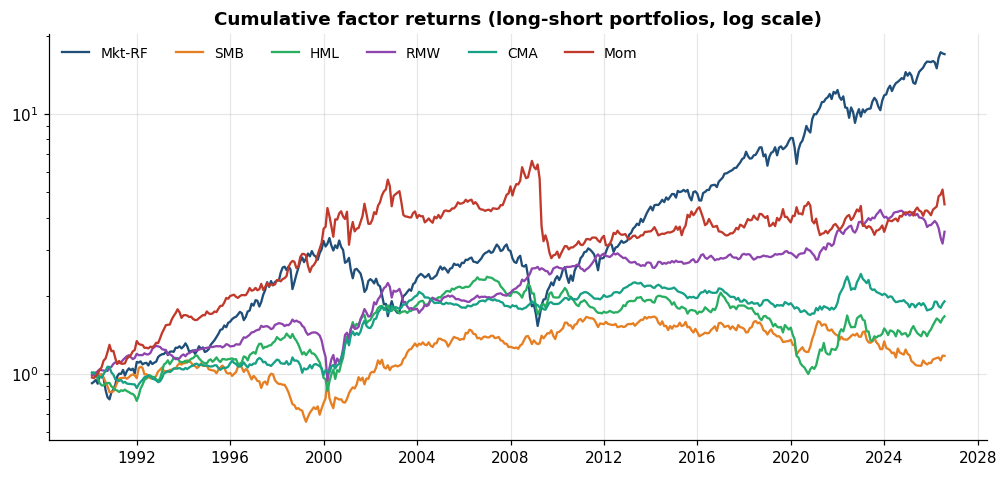

In [11]:
t0 = time.time()
tickers = list(assets) + [t for t in portfolio if t not in assets]
D = data.load_all(tickers, DATA)
returns = D["returns"]
print(f"prices loaded in {time.time()-t0:.1f}s | {D['prices'].index[0].date()} -> {D['prices'].index[-1].date()}")
for k, v in D["issues"].items(): print(f"  {k}: {v}")

F = french.load_factors(REGION, FREQUENCY, DATA)
print(f"\nFrench factors ({REGION}, {FREQUENCY}): {F.index[0].date()} -> {F.index[-1].date()} ({len(F)} periods). "
      f"The library publishes with a lag of roughly six weeks, so the sample ends at the last factor date.")
display(F.tail(3).style.format("{:.2%}"))
fig = plots.plot_cumulative_factors(F.loc["1990":], ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]); plots.save(fig, "01_factors"); plt.show()

In [12]:
# Blend the portfolio into a single return series (monthly rebalance within the daily data), then align everything to the factor calendar
w = pd.Series(portfolio); w = w / w.sum()
port_daily = (returns[w.index] * w).sum(axis=1, min_count=len(w))    # equal to monthly-rebalanced if resampled monthly below
asset_returns = returns[list(assets)].copy(); asset_returns[PORTFOLIO_NAME] = port_daily
excess, f = fx.align(asset_returns, F, FREQUENCY)
print(f"aligned sample: {excess.index[0].date()} -> {excess.index[-1].date()}")
display(excess.notna().sum().rename("observations").to_frame().T)
excess.to_csv("outputs/tables/excess_returns.csv"); f.to_csv("outputs/tables/factors_aligned.csv")

aligned sample: 2005-01-31 -> 2026-07-31


,BRK-B,ARKK,VTV,MTUM,QUAL,IWM,USMV,Project-1 multi-asset portfolio
observations,259,141,259,160,157,259,178,259


## 5. Does the alpha survive? Model comparison for one asset

Five nested models. Watch alpha, its HAC t-statistic and adjusted R² as factors are added. If
alpha collapses toward zero while R² rises, the "skill" was factor exposure. The Newey-West
t-stat is the one to trust; the OLS t-stat is shown to make the difference visible.

,n_obs,alpha_ann,t_alpha_ols,t_alpha_hac,p_alpha_hac,adj_r2,resid_vol_ann,info_ratio,bic
CAPM,259,+3.72%,1.17,1.23,0.220,0.299,14.55%,0.26,-1633
FF3,259,+3.25%,1.09,1.26,0.211,0.386,13.61%,0.24,-1658
Carhart4,259,+3.45%,1.15,1.30,0.194,0.385,13.63%,0.25,-1653
FF5,259,+2.82%,0.93,1.05,0.293,0.384,13.64%,0.21,-1648
FF5+Mom,259,+3.05%,1.00,1.10,0.271,0.383,13.66%,0.22,-1643


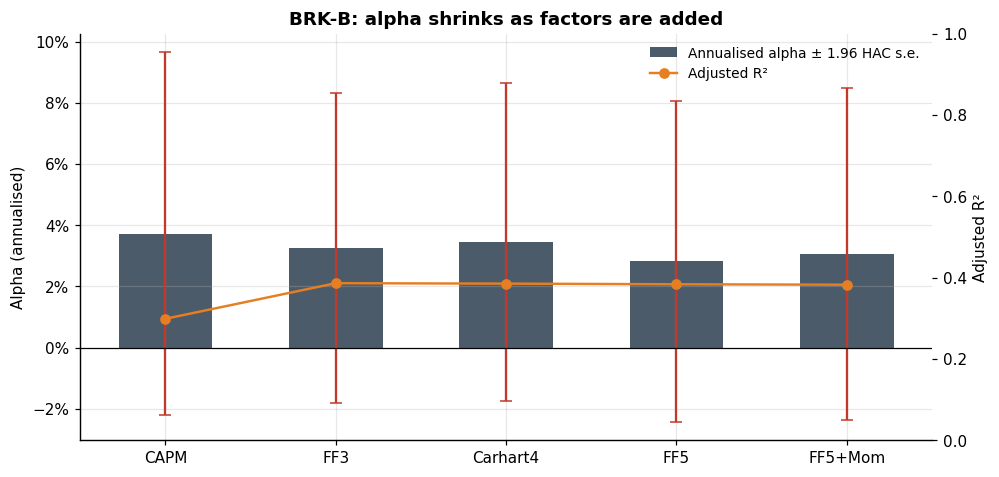

In [13]:
res = fx.fit_models(excess[FOCUS].dropna(), f, FOCUS, MODELS, cfg)
cmp = fx.comparison_table(res)
cmp.to_csv(f"outputs/tables/model_comparison_{FOCUS}.csv")
cols = ["n_obs", "alpha_ann", "t_alpha_ols", "t_alpha_hac", "p_alpha_hac", "adj_r2", "resid_vol_ann", "info_ratio", "bic"]
display(cmp[cols].style.format({"n_obs": "{:.0f}", "alpha_ann": "{:+.2%}", "t_alpha_ols": "{:.2f}", "t_alpha_hac": "{:.2f}", "p_alpha_hac": "{:.3f}",
                                 "adj_r2": "{:.3f}", "resid_vol_ann": "{:.2%}", "info_ratio": "{:.2f}", "bic": "{:.0f}"})
        .background_gradient(subset=["adj_r2"], cmap="Blues"))
fig = plots.plot_alpha_across_models(cmp, FOCUS); plots.save(fig, f"02_alpha_models_{FOCUS}"); plt.show()

## 6. Loadings with Newey-West confidence intervals

,estimate,se_ols,se_hac,t_hac,ci_low,ci_high,hac_vs_ols
alpha,+0.0025,0.0025,0.0023,1.10,-0.002,+0.007,0.91x
Mkt-RF,+0.6684,0.0629,0.0884,7.56,+0.494,+0.843,1.41x
SMB,-0.3719,0.1095,0.1026,-3.63,-0.574,-0.170,0.94x
HML,+0.4116,0.1071,0.1264,3.26,+0.163,+0.661,1.18x
RMW,+0.0761,0.1266,0.1144,0.67,-0.149,+0.301,0.90x
CMA,+0.1078,0.1631,0.1731,0.62,-0.233,+0.449,1.06x
Mom,-0.0474,0.0631,0.0749,-0.63,-0.195,+0.100,1.19x


Newey-West lags: 4. 'hac_vs_ols' > 1 means OLS understated the uncertainty.


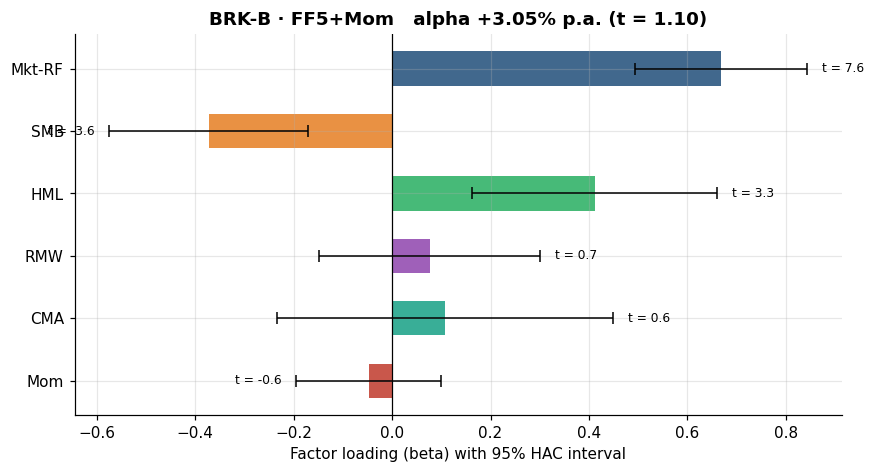

In [14]:
BEST = "FF5+Mom"
ct = fx.coefficient_table(res[BEST], cfg.confidence)
display(ct.style.format({"estimate": "{:+.4f}", "se_ols": "{:.4f}", "se_hac": "{:.4f}", "t_hac": "{:.2f}", "ci_low": "{:+.3f}", "ci_high": "{:+.3f}", "hac_vs_ols": "{:.2f}x"}))
print(f"Newey-West lags: {res[BEST].hac_lags}. 'hac_vs_ols' > 1 means OLS understated the uncertainty.")
fig = plots.plot_coefficients(ct, FOCUS, BEST); plots.save(fig, f"03_coefficients_{FOCUS}"); plt.show()

## 7. Style drift: rolling loadings

A 36-month rolling window. Stable loadings mean the strategy is what it says it is; wandering
loadings mean the fund's risk is changing under the investor. The style map traces the size
and value loadings through time — the classic style box, animated.

,mean,std,min,max,range,sign_flips,latest
Mkt-RF,+1.53,0.21,+0.94,+1.95,1.01,0,+1.85
SMB,+0.52,0.29,-0.11,+1.09,1.20,4,+0.61
HML,-0.67,0.38,-1.23,+0.22,1.45,2,-0.79
RMW,-1.08,0.55,-2.44,-0.32,2.12,0,-1.21
CMA,-0.60,0.58,-1.98,+0.54,2.52,3,+0.10
Mom,-0.22,0.20,-0.66,+0.21,0.87,8,-0.47


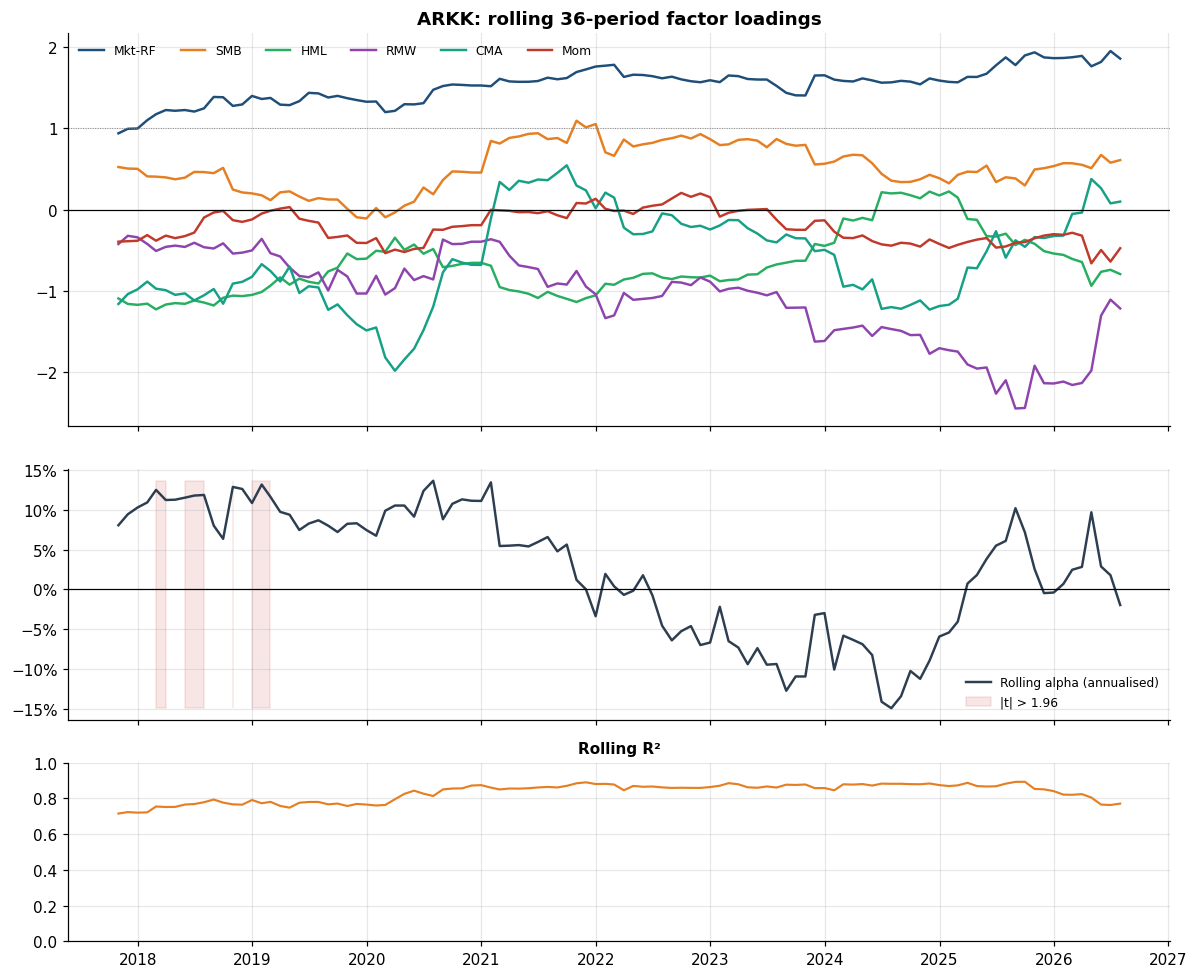

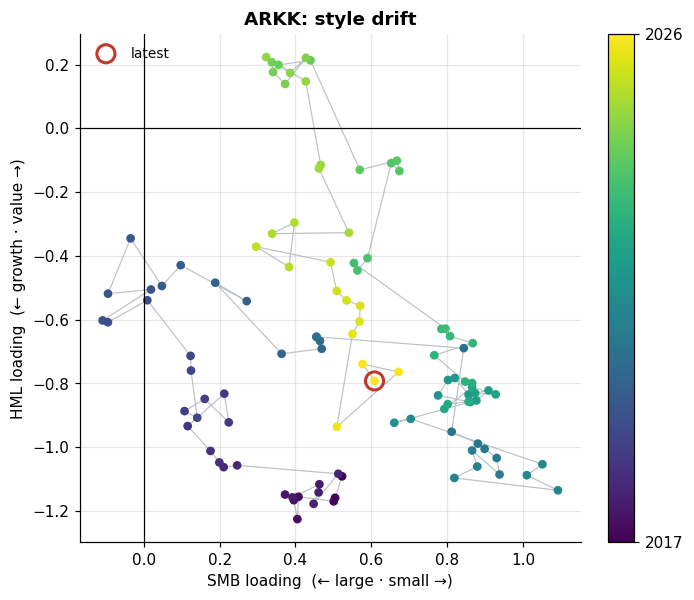

In [15]:
DRIFT = "ARKK" if "ARKK" in excess.columns else FOCUS
fac6 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
rr = fx.rolling_regression(excess[DRIFT].dropna(), f[fac6], cfg.rolling_window, FREQUENCY)
drift = fx.style_drift(rr["coef"], fac6)
display(drift.style.format({"mean": "{:+.2f}", "std": "{:.2f}", "min": "{:+.2f}", "max": "{:+.2f}", "range": "{:.2f}", "sign_flips": "{:.0f}", "latest": "{:+.2f}"})
        .background_gradient(subset=["range"], cmap="Reds"))
fig = plots.plot_rolling_loadings(rr, DRIFT, fac6, cfg.rolling_window); plots.save(fig, f"04_rolling_{DRIFT}"); plt.show()
fig = plots.plot_style_map(rr, DRIFT); plots.save(fig, f"05_style_map_{DRIFT}"); plt.show()
rr["coef"].to_csv(f"outputs/tables/rolling_loadings_{DRIFT}.csv")

## 8. Where did the return come from?

Average annualised excess return = alpha + Σ βₖ · E[fₖ]. The right-hand panel accumulates the
same decomposition through time (additive period returns, so the pieces sum exactly).

,ann_contribution,share_of_total
alpha,+3.05%,+30.8%
Mkt-RF,+6.64%,+67.0%
SMB,+0.11%,+1.1%
HML,-0.07%,-0.7%
RMW,+0.24%,+2.4%
CMA,+0.03%,+0.3%
Mom,-0.09%,-0.9%
total_excess_return,+9.91%,+100.0%


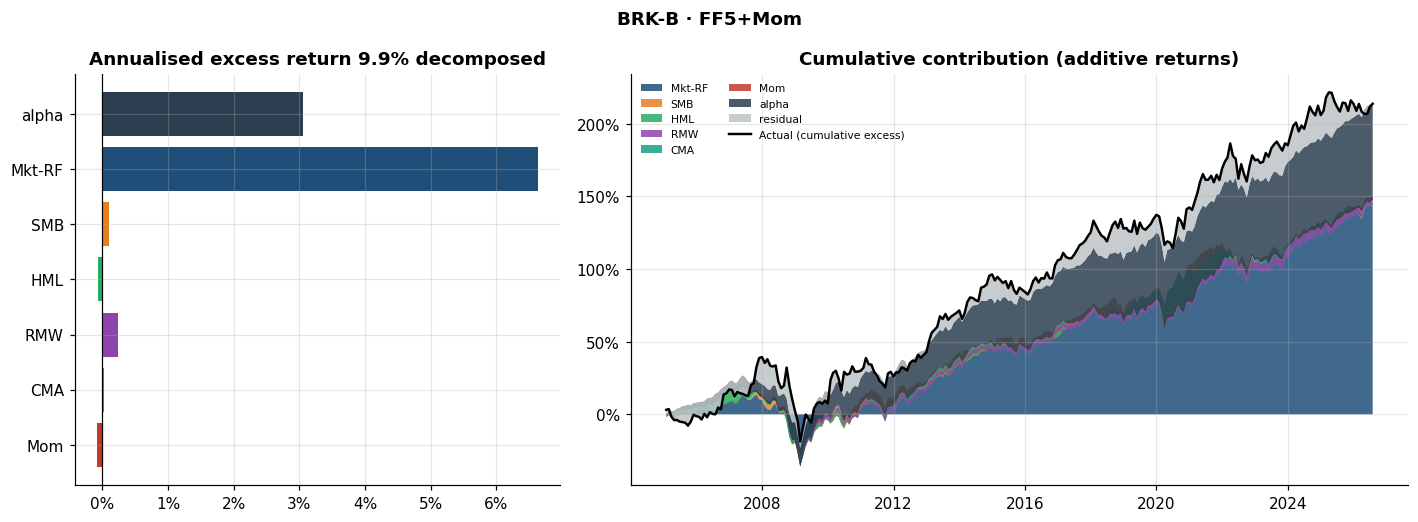

In [16]:
att = fx.attribution(res[BEST])
display(att["table"].style.format({"ann_contribution": "{:+.2%}", "share_of_total": "{:+.1%}"}))
fig = plots.plot_attribution(att, FOCUS, BEST, FREQUENCY); plots.save(fig, f"06_attribution_{FOCUS}"); plt.show()

## 9. Can the regression be trusted?

Residual diagnostics. Heteroskedasticity (ARCH) is nearly universal in monthly returns, which
is why HAC errors are the default here. Autocorrelation in residuals would point to stale
pricing (illiquid holdings, smoothed NAVs) and understated risk.

,statistic,p_value,null hypothesis
test,,,
Jarque-Bera (normality),164.227,0.000,residuals are normal
Ljung-Box Q (autocorrelation),11.125,0.518,no autocorrelation up to lag 12
Durbin-Watson,2.111,nan,≈2 means no first-order autocorrelation
ARCH LM (heteroskedasticity),3.264,0.515,constant residual variance
Skew,1.047,nan,
Excess kurtosis,3.291,nan,


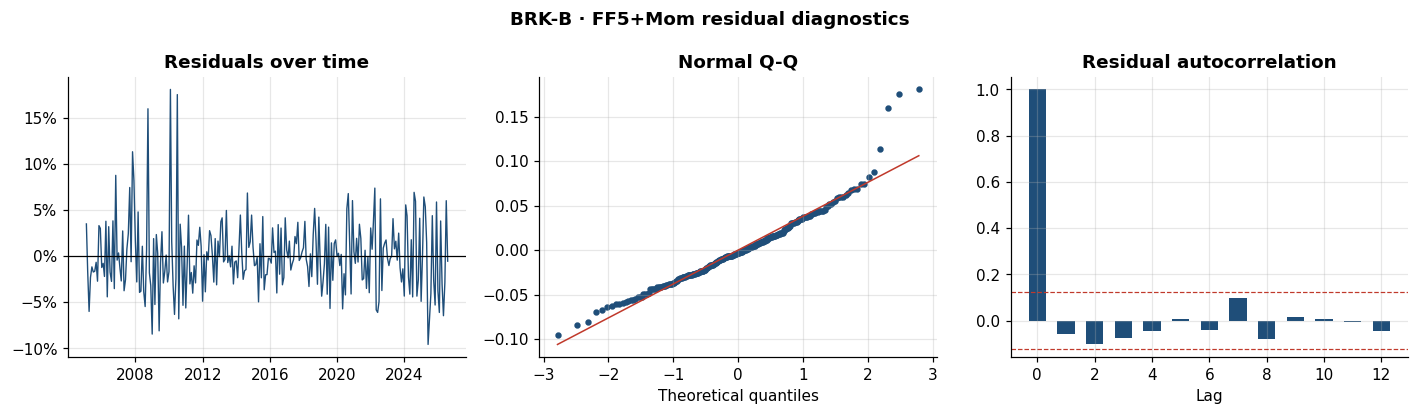

In [17]:
diag = fx.residual_diagnostics(res[BEST])
display(diag.style.format({"statistic": "{:.3f}", "p_value": "{:.3f}"}))
fig = plots.plot_residuals(res[BEST]); plots.save(fig, f"07_residuals_{FOCUS}"); plt.show()

## 10. Cross-section: who actually has alpha?

Every asset on the same model. With eight assets, one will show a raw p < 0.05 by chance about a
third of the time, so the table also reports Benjamini-Hochberg adjusted p-values; those are the
ones that survive the fact that you looked at several funds. (Harvey, Liu & Zhu argue the bar for
a *new factor* should be t > 3 for the same reason.)

,n_obs,alpha_ann,t_alpha_hac,p_alpha_hac,p_alpha_bh,adj_r2,info_ratio
Project-1 multi-asset portfolio,259,+1.32%,1.41,0.158,0.477,0.813,0.30
BRK-B,259,+3.05%,1.10,0.271,0.477,0.383,0.22
ARKK,141,+1.72%,0.39,0.696,0.698,0.782,0.10
MTUM,160,-0.61%,-0.39,0.698,0.698,0.888,-0.11
USMV,178,-0.82%,-0.56,0.573,0.698,0.773,-0.15
QUAL,157,-0.86%,-1.04,0.298,0.477,0.949,-0.26
VTV,259,-0.67%,-1.07,0.285,0.477,0.952,-0.21
IWM,259,-0.91%,-2.28,0.023,0.186,0.991,-0.47


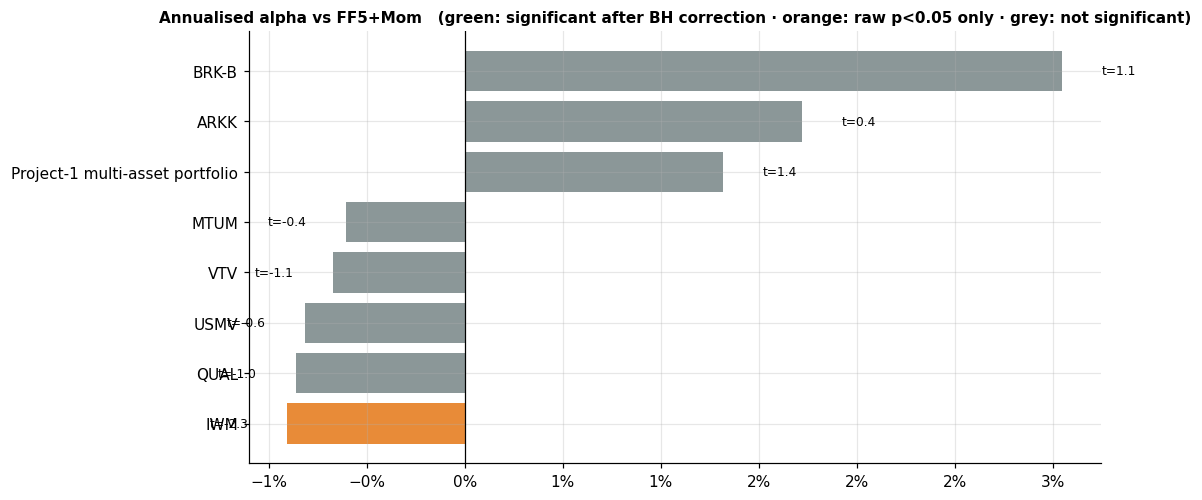

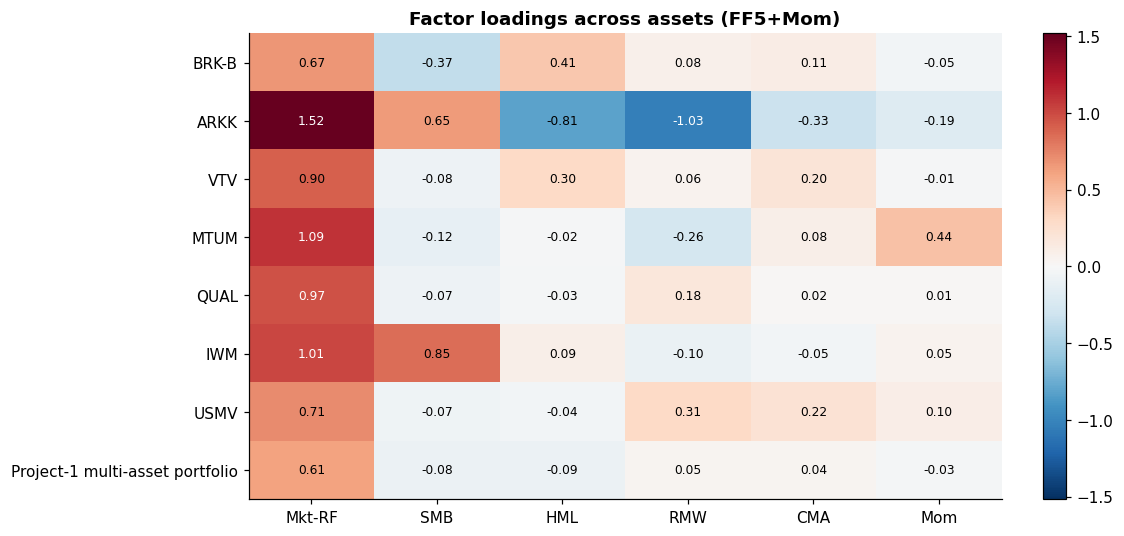

In [18]:
cs = fx.cross_section(excess, f, BEST, cfg)
cs.to_csv(f"outputs/tables/cross_section_{BEST}.csv")
show = ["n_obs", "alpha_ann", "t_alpha_hac", "p_alpha_hac", "p_alpha_bh", "adj_r2", "info_ratio"]
display(cs[show].sort_values("t_alpha_hac", ascending=False).style.format({"n_obs": "{:.0f}", "alpha_ann": "{:+.2%}", "t_alpha_hac": "{:.2f}", "p_alpha_hac": "{:.3f}", "p_alpha_bh": "{:.3f}", "adj_r2": "{:.3f}", "info_ratio": "{:.2f}"})
        .background_gradient(subset=["p_alpha_bh"], cmap="Greens_r", vmin=0, vmax=0.5))
fig = plots.plot_alpha_cross_section(cs, BEST); plots.save(fig, "08_alpha_cross_section"); plt.show()
expo = fx.exposures_matrix(cs)
fig = plots.plot_exposure_heatmap(expo, BEST); plots.save(fig, "09_exposures"); plt.show()

Read the heat-map against the reasons each asset was chosen (§3): VTV should be positive on HML,
MTUM on Mom, QUAL on RMW, IWM on SMB, USMV below 1 on Mkt-RF. If the loadings match the labels,
the machinery works; the interesting rows are the active names.

## 11. A portfolio as a single asset

,n_obs,alpha_ann,t_alpha_ols,t_alpha_hac,p_alpha_hac,adj_r2,resid_vol_ann,info_ratio,bic
CAPM,259,+1.66%,1.67,1.60,0.111,0.800,4.53%,0.37,-2237
FF3,259,+1.39%,1.44,1.47,0.143,0.812,4.39%,0.32,-2244
Carhart4,259,+1.53%,1.59,1.65,0.101,0.813,4.38%,0.35,-2241
FF5,259,+1.16%,1.19,1.22,0.225,0.812,4.39%,0.26,-2235
FF5+Mom,259,+1.32%,1.35,1.41,0.158,0.813,4.38%,0.30,-2232


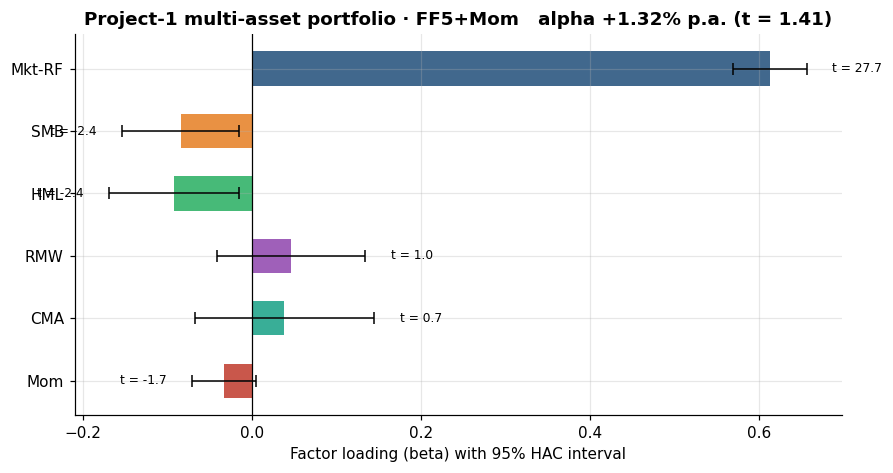

A multi-asset portfolio has a low R² against *equity* factors by construction: bonds, gold and REITs are not spanned by them. That unexplained part is not alpha; it is exposure to factors this model does not contain (duration, credit, commodity). See the upgrades.


In [19]:
resP = fx.fit_models(excess[PORTFOLIO_NAME].dropna(), f, PORTFOLIO_NAME, MODELS, cfg)
cmpP = fx.comparison_table(resP)
display(cmpP[cols].style.format({"n_obs": "{:.0f}", "alpha_ann": "{:+.2%}", "t_alpha_ols": "{:.2f}", "t_alpha_hac": "{:.2f}", "p_alpha_hac": "{:.3f}",
                                   "adj_r2": "{:.3f}", "resid_vol_ann": "{:.2%}", "info_ratio": "{:.2f}", "bic": "{:.0f}"}))
ctP = fx.coefficient_table(resP[BEST]); fig = plots.plot_coefficients(ctP, PORTFOLIO_NAME, BEST); plots.save(fig, "10_portfolio_coefficients"); plt.show()
print("A multi-asset portfolio has a low R² against *equity* factors by construction: bonds, gold and REITs are not spanned by them. "
      "That unexplained part is not alpha; it is exposure to factors this model does not contain (duration, credit, commodity). See the upgrades.")

## 12. Reading the results

Write your own after each run; the pattern on the default set:

1. **Berkshire.** The alpha is positive under every model (about 3–4% a year over 2005–2026)
   and statistically insignificant under every model (HAC t ≈ 1.1–1.3). Adding value and
   profitability trims it but does not remove it; R² stays below 0.4 because a single stock
   carries a lot of idiosyncratic risk. The loadings are the informative part: beta around 0.8,
   negative size, positive value, positive profitability. The published "Buffett's Alpha" result
   (Frazzini, Kabiller & Pedersen) needs the betting-against-beta and quality-minus-junk factors
   to close the gap fully; those are the first upgrade below. Try `FOCUS = "BRK-B"` on a
   2014-onward sample and the alpha does collapse to zero, which is a reminder that the answer
   depends on the window.
2. **ARKK.** Beta around 1.5, strongly negative RMW (unprofitable growth) and negative HML. The
   rolling loadings wander and the alpha changes sign across sub-periods, which is what style
   drift looks like in numbers.
3. **The style ETFs load where they should**, with R² above 0.9. That is the sanity check that
   the regressions are wired correctly.
4. **Nobody survives the multiple-testing correction.** Every Benjamini-Hochberg adjusted
   p-value is above 0.05. The passive style ETFs show small negative alphas, which is what fees
   plus imperfect tracking of an academic long-short factor should produce.
5. **OLS t-stats overstate significance** relative to HAC by 20–40% for the active names. If a
   fund's pitch book quotes a t-stat, ask which one.

**Caveats.** The French factors are academic long-short portfolios, not investable ETFs; a fund
can have zero alpha against them and still be worth holding if it delivers the exposure more
cheaply than the alternatives. International assets should be run against the regional factor
sets, not the US ones. Fund NAVs with stale pricing bias betas toward zero; use monthly data and
check the Ljung-Box statistic.

## 13. Potential upgrades

| Upgrade | Why |
|---|---|
| Add AQR factors (QMJ, BAB) and a bond/credit/commodity factor set | Explains multi-asset portfolios; completes the Buffett decomposition |
| Bayesian shrinkage of loadings toward a prior (e.g. a benchmark's) | Rolling 36-month betas are noisy; shrinkage stabilises them |
| Regime-conditional loadings (up vs down markets, high vs low VIX) | Beta asymmetry is where a lot of "alpha" hides |
| Returns-based style analysis (Sharpe 1992) with long-only constraints | The practitioner alternative when factors must be investable indices |
| Bootstrap and White's reality check across the fund universe | Formal multiple-testing control beyond BH |
| Point-in-time fund universe with survivorship handling (CRSP mutual fund style) | The cross-section is biased if dead funds are missing |